# 04 — Evaluation, post-processing, and ablation study

This notebook evaluates the cosine-similarity cell-type assignments from Notebook 03 and runs a small ablation study to test whether biological correction improves Cellpose segmentation.

The goal is not just to run one correction setting. We explicitly test multiple post-processing configurations so the final report can say we tried different refinement strategies and measured whether they improved biological consistency.

## What this notebook does

1. Loads the Cellpose baseline outputs.
2. Evaluates marker-gene consistency.
3. Computes confidence and margin scores.
4. Runs several biological correction experiments:
   - baseline / no correction
   - strict correction
   - relaxed correction
   - larger crop correction
   - worst-cells-only correction
5. Compares cosine similarity before vs. after each experiment.
6. Saves metrics, plots, and example corrected cells.


## Imports

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

try:
    from cellpose import models
    CELLPOSE_AVAILABLE = True
except Exception as e:
    CELLPOSE_AVAILABLE = False
    print("Cellpose import failed. Re-segmentation experiments will be skipped.")
    print(e)


## Config

In [2]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Core files from Notebooks 02 and 03
CELL_EXPR_PATH = OUTPUT_DIR / "cell_expression_aligned.csv"
PROTOTYPES_PATH = OUTPUT_DIR / "prototypes_normalized.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "cell_type_predictions.csv"
SIM_MATRIX_PATH = OUTPUT_DIR / "cosine_similarity_matrix.csv"
ASSIGNED_TRANSCRIPTS_PATH = OUTPUT_DIR / "assigned_transcripts_crop.csv"

# Segmentation/image files
MASK_PATH = DATA_DIR / "masks_center.npy"
MORPHOLOGY_DIR = DATA_DIR / "morphology_focus"

# Main final outputs
BEST_REFINED_PATH = OUTPUT_DIR / "cell_type_predictions_refined_best.csv"
ALL_RESULTS_PATH = OUTPUT_DIR / "ablation_all_cell_results.csv"
EXPERIMENT_METRICS_PATH = OUTPUT_DIR / "ablation_experiment_metrics.csv"

CROP_SIZE = 512
EXPECTED_SHARED_GENES = 5054
DEFAULT_CONFIDENCE_THRESHOLD = 0.5
DEFAULT_MARGIN_THRESHOLD = 0.05

MARKER_GENES = {
    "fibroblast": ["COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA"],
    "myofibroblast": ["ACTA2", "TAGLN", "MYL9", "COL3A1"],
    "endothelial": ["PECAM1", "VWF", "KDR", "RAMP2", "ENG"],
    "pericyte": ["RGS5", "PDGFRB", "MCAM", "CSPG4"],
    "vascular_smooth_muscle": ["ACTA2", "MYH11", "TAGLN", "MYLK"],
    "cycling": ["MKI67", "TOP2A", "UBE2C", "CENPF"],
    "immune": ["PTPRC", "CD3D", "CD3E", "MS4A1", "LYZ"],
    "epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
}


## Helper functions

In [3]:
def require_file(path: Path, description: str):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {description}: {path}\n"
            "Check the previous notebooks and path configuration."
        )


def savefig(name: str, dpi: int = 300):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")


def find_first_morphology_image(morphology_dir: Path) -> Path:
    image_files = sorted(
        list(morphology_dir.glob("*.ome.tif")) +
        list(morphology_dir.glob("*.ome.tiff")) +
        list(morphology_dir.glob("*.tif")) +
        list(morphology_dir.glob("*.tiff"))
    )
    if len(image_files) == 0:
        raise FileNotFoundError(f"No TIFF images found in {morphology_dir}")
    return image_files[0]


def parse_cell_id(cell_id_like):
    try:
        return int(str(cell_id_like).replace("cell_", ""))
    except Exception:
        return None


def load_center_crop(image_path: Path, crop_size: int):
    with tiff.TiffFile(image_path) as tif:
        img = tif.pages[0].asarray()
    if img.ndim == 3:
        img = img[..., 0]
    h, w = img.shape
    start_y = h // 2 - crop_size // 2
    start_x = w // 2 - crop_size // 2
    crop = img[start_y:start_y + crop_size, start_x:start_x + crop_size].astype(float)
    crop_norm = (crop - crop.min()) / (crop.max() - crop.min() + 1e-8)
    return crop_norm, start_x, start_y


def compute_margin(similarity_matrix: pd.DataFrame) -> np.ndarray:
    if similarity_matrix.shape[1] < 2:
        raise ValueError("Need at least two prototype columns to compute margin.")
    sorted_scores = np.sort(similarity_matrix.values, axis=1)
    return sorted_scores[:, -1] - sorted_scores[:, -2]


def add_confidence_flags(pred_df, sim_matrix, confidence_threshold, margin_threshold):
    pred_df = pred_df.copy()
    pred_df["confidence"] = pred_df["best_similarity"]
    pred_df["margin"] = compute_margin(sim_matrix)
    pred_df["low_similarity"] = pred_df["confidence"] < confidence_threshold
    pred_df["low_margin"] = pred_df["margin"] < margin_threshold
    pred_df["low_confidence"] = pred_df["low_similarity"] | pred_df["low_margin"]
    return pred_df


@dataclass
class AblationConfig:
    name: str
    confidence_threshold: float
    margin_threshold: float
    patch_size: int
    retry_diameter: int
    accept_tolerance: float
    worst_quantile: Optional[float] = None
    run_resegmentation: bool = True


## 1 · Load data

In [4]:
require_file(CELL_EXPR_PATH, "cell expression matrix")
require_file(PROTOTYPES_PATH, "normalized prototypes")
require_file(PREDICTIONS_PATH, "cell type predictions")
require_file(SIM_MATRIX_PATH, "cosine similarity matrix")
require_file(MASK_PATH, "Cellpose mask")
require_file(ASSIGNED_TRANSCRIPTS_PATH, "assigned transcript table")

cells = pd.read_csv(CELL_EXPR_PATH, index_col=0)
prototypes = pd.read_csv(PROTOTYPES_PATH, index_col=0)
predictions_raw = pd.read_csv(PREDICTIONS_PATH, index_col=0)
sim_df = pd.read_csv(SIM_MATRIX_PATH, index_col=0)
masks = np.load(MASK_PATH)
assigned_tx = pd.read_csv(ASSIGNED_TRANSCRIPTS_PATH)

print("Cells:", cells.shape)
print("Prototypes:", prototypes.shape)
print("Predictions:", predictions_raw.shape)
print("Similarity matrix:", sim_df.shape)
print("Masks:", masks.shape)
print("Assigned transcripts:", assigned_tx.shape)

if cells.shape[1] != prototypes.shape[1]:
    raise ValueError(f"Gene mismatch: cells have {cells.shape[1]} genes, prototypes have {prototypes.shape[1]} genes.")

if cells.shape[1] != EXPECTED_SHARED_GENES:
    print(f"Warning: expected {EXPECTED_SHARED_GENES} genes, but cell expression has {cells.shape[1]} genes.")

required_tx_cols = {"x_local", "y_local", "feature_name"}
missing_tx_cols = required_tx_cols - set(assigned_tx.columns)
if missing_tx_cols:
    raise ValueError(f"assigned_transcripts_crop.csv is missing columns: {missing_tx_cols}")

common_cells = cells.index.intersection(predictions_raw.index).intersection(sim_df.index)
if len(common_cells) == 0:
    raise ValueError("No overlapping cell IDs among cells, predictions, and similarity matrix. Check cell_1 vs 1 formatting.")

cells = cells.loc[common_cells].copy()
predictions_raw = predictions_raw.loc[common_cells].copy()
sim_df = sim_df.loc[common_cells].copy()

print("\nAfter cell-index alignment:")
print("Cells:", cells.shape)
print("Predictions:", predictions_raw.shape)
print("Similarity matrix:", sim_df.shape)

print("\nPredicted cell type counts:")
print(predictions_raw["predicted_cell_type"].value_counts())


Cells: (82, 5054)
Prototypes: (8, 5054)
Predictions: (82, 2)
Similarity matrix: (82, 8)
Masks: (512, 512)
Assigned transcripts: (74005, 6)

After cell-index alignment:
Cells: (82, 5054)
Predictions: (82, 2)
Similarity matrix: (82, 8)

Predicted cell type counts:
predicted_cell_type
endothelial cell                          30
vein endothelial cell                     16
fibroblast                                12
pericyte                                   8
endothelial cell of artery                 5
myofibroblast cell                         5
endothelial cell of vascular tree          4
vascular associated smooth muscle cell     2
Name: count, dtype: int64


## 2 · Load image crop for spatial plots and correction

Using image: ../data/morphology_focus/morphology_focus_0000.ome.tif


Image crop shape: (512, 512)
Saved → ../outputs/figures/evaluation_center_crop.png


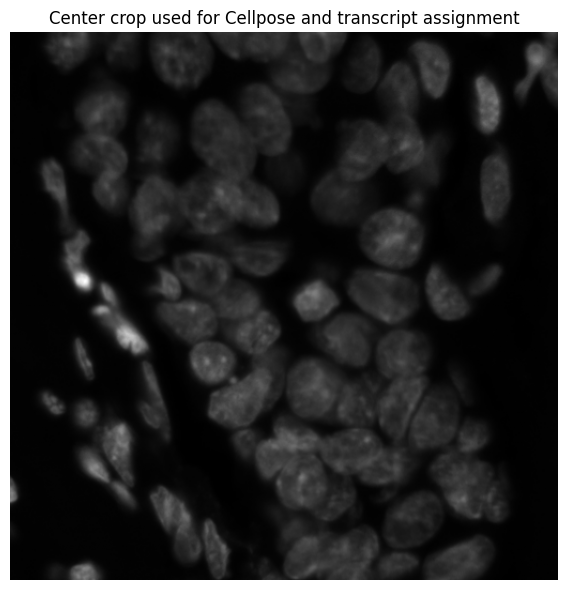

In [5]:
IMAGE_PATH = find_first_morphology_image(MORPHOLOGY_DIR)
print(f"Using image: {IMAGE_PATH}")
img_crop, start_x, start_y = load_center_crop(IMAGE_PATH, CROP_SIZE)
print("Image crop shape:", img_crop.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_crop, cmap="gray")
ax.set_title("Center crop used for Cellpose and transcript assignment")
ax.axis("off")
plt.tight_layout()
savefig("evaluation_center_crop.png")
plt.show()


## 3 · Marker gene evaluation

In [6]:
available_markers = {}
for marker_group, genes in MARKER_GENES.items():
    present = [g for g in genes if g in cells.columns]
    missing = [g for g in genes if g not in cells.columns]
    if present:
        available_markers[marker_group] = present
    if missing:
        print(f"{marker_group}: markers not in panel/expression matrix: {missing}")

print("\nMarkers available for evaluation:")
for marker_group, genes in available_markers.items():
    print(f"{marker_group}: {genes}")

if len(available_markers) == 0:
    raise ValueError("No marker genes were found in the cell expression matrix.")

cells_with_pred = cells.copy()
cells_with_pred["predicted_cell_type"] = predictions_raw["predicted_cell_type"]
rows = []
for marker_group, genes in available_markers.items():
    mean_expr = cells_with_pred.groupby("predicted_cell_type")[genes].mean().mean(axis=1)
    mean_expr.name = marker_group
    rows.append(mean_expr)

marker_df = pd.DataFrame(rows).fillna(0)
marker_df_norm = marker_df.div(marker_df.max(axis=1) + 1e-9, axis=0)
print("Marker matrix:", marker_df.shape)
display(marker_df)
display(marker_df_norm)


fibroblast: markers not in panel/expression matrix: ['COL1A1', 'COL1A2']
myofibroblast: markers not in panel/expression matrix: ['ACTA2', 'TAGLN', 'COL3A1']
endothelial: markers not in panel/expression matrix: ['VWF', 'RAMP2']
vascular_smooth_muscle: markers not in panel/expression matrix: ['ACTA2', 'TAGLN']
immune: markers not in panel/expression matrix: ['PTPRC', 'LYZ']
epithelial: markers not in panel/expression matrix: ['KRT8', 'KRT18', 'KRT19']

Markers available for evaluation:
fibroblast: ['DCN', 'LUM', 'PDGFRA']
myofibroblast: ['MYL9']
endothelial: ['PECAM1', 'KDR', 'ENG']
pericyte: ['RGS5', 'PDGFRB', 'MCAM', 'CSPG4']
vascular_smooth_muscle: ['MYH11', 'MYLK']
cycling: ['MKI67', 'TOP2A', 'UBE2C', 'CENPF']
immune: ['CD3D', 'CD3E', 'MS4A1']
epithelial: ['EPCAM']
Marker matrix: (8, 8)


predicted_cell_type,endothelial cell,endothelial cell of artery,endothelial cell of vascular tree,fibroblast,myofibroblast cell,pericyte,vascular associated smooth muscle cell,vein endothelial cell
fibroblast,0.000000,0.0,0.0,0.166667,0.0,0.0000,0.0,0.000000
myofibroblast,0.000000,0.0,0.0,0.416667,1.2,0.0000,0.0,0.312500
endothelial,0.277778,0.0,0.0,0.277778,0.0,0.0000,0.0,0.395833
pericyte,0.000000,0.0,0.0,0.000000,0.0,0.0000,0.0,0.000000
vascular_smooth_muscle,0.250000,0.7,0.0,0.000000,0.2,0.3125,0.0,0.062500
cycling,0.166667,0.3,0.0,0.312500,0.0,0.0000,0.0,0.000000
immune,0.311111,0.0,0.0,0.000000,0.0,0.3750,0.0,0.083333
epithelial,0.000000,0.0,0.0,0.000000,0.0,0.0000,0.0,0.000000


predicted_cell_type,endothelial cell,endothelial cell of artery,endothelial cell of vascular tree,fibroblast,myofibroblast cell,pericyte,vascular associated smooth muscle cell,vein endothelial cell
fibroblast,0.000000,0.00,0.0,1.000000,0.000000,0.000000,0.0,0.000000
myofibroblast,0.000000,0.00,0.0,0.347222,1.000000,0.000000,0.0,0.260417
endothelial,0.701754,0.00,0.0,0.701754,0.000000,0.000000,0.0,1.000000
pericyte,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000
vascular_smooth_muscle,0.357143,1.00,0.0,0.000000,0.285714,0.446429,0.0,0.089286
cycling,0.533333,0.96,0.0,1.000000,0.000000,0.000000,0.0,0.000000
immune,0.829630,0.00,0.0,0.000000,0.000000,1.000000,0.0,0.222222
epithelial,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000


Saved → ../outputs/figures/marker_gene_heatmap_ordered.png


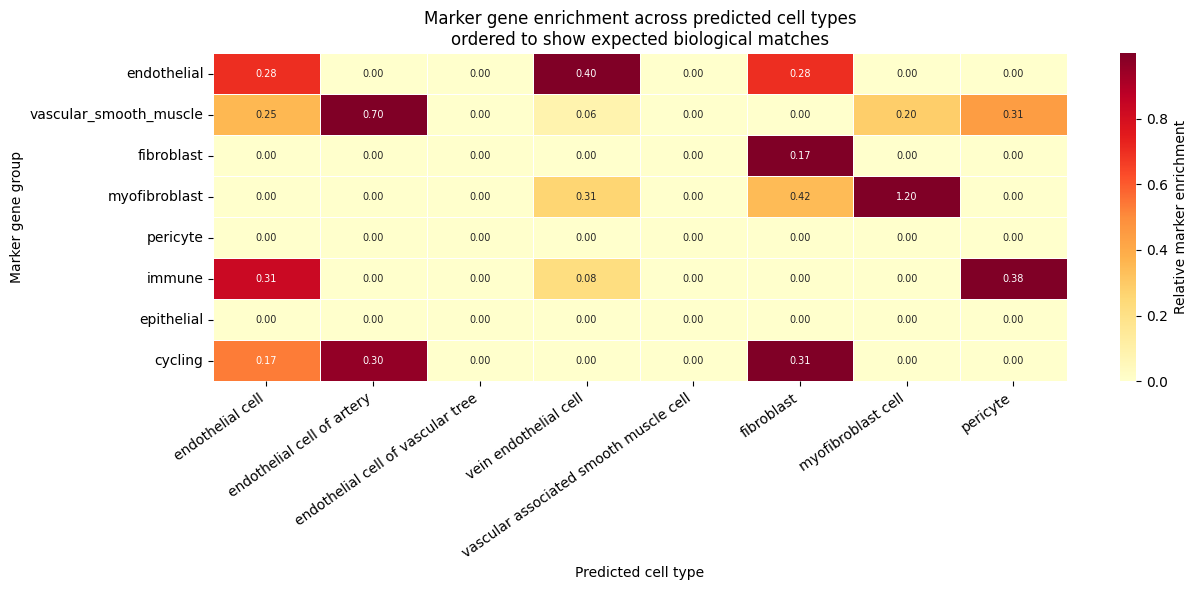

In [7]:
# =========================
# Marker heatmap with matched row/column ordering
# =========================

# Map marker groups to the closest matching predicted cell type names
marker_to_predicted_type = {
    "endothelial": "endothelial cell",
    "vascular_smooth_muscle": "vascular associated smooth muscle cell",
    "fibroblast": "fibroblast",
    "myofibroblast": "myofibroblast cell",
    "pericyte": "pericyte",
    "immune": None,        # no matching predicted immune cell type
    "epithelial": None,    # no matching predicted epithelial cell type
    "cycling": None,       # no matching predicted cycling cell type
}

# Put matched marker groups first, then unmatched groups at the end
ordered_marker_groups = [
    "endothelial",
    "vascular_smooth_muscle",
    "fibroblast",
    "myofibroblast",
    "pericyte",
    "immune",
    "epithelial",
    "cycling",
]

ordered_cell_types = [
    "endothelial cell",
    "endothelial cell of artery",
    "endothelial cell of vascular tree",
    "vein endothelial cell",
    "vascular associated smooth muscle cell",
    "fibroblast",
    "myofibroblast cell",
    "pericyte",
]

# Keep only rows/columns that actually exist
ordered_marker_groups = [m for m in ordered_marker_groups if m in marker_df_norm.index]
ordered_cell_types = [c for c in ordered_cell_types if c in marker_df_norm.columns]

marker_df_plot = marker_df_norm.loc[ordered_marker_groups, ordered_cell_types]
marker_df_annot = marker_df.loc[ordered_marker_groups, ordered_cell_types]

fig, ax = plt.subplots(figsize=(13, 6))

sns.heatmap(
    marker_df_plot,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.4,
    annot=marker_df_annot.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Relative marker enrichment"}
)

ax.set_title(
    "Marker gene enrichment across predicted cell types\n"
    "ordered to show expected biological matches"
)
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Marker gene group")

plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

savefig("marker_gene_heatmap_ordered.png")
plt.show()

### Interpretation of marker gene enrichment heatmap

This heatmap evaluates whether the cell-type predictions are biologically consistent with known marker gene groups. In an ideal case, we would expect a strong diagonal pattern, where each marker gene group is most enriched in its corresponding predicted cell type. However, the observed pattern is only partially diagonal, which suggests that the predictions contain some biological signal but are still noisy and ambiguous.

The strongest and cleanest signal appears for the **myofibroblast** marker group, which is highly enriched in the predicted **myofibroblast cell** category. This supports that at least some predicted cell types are biologically meaningful. The **fibroblast** marker group also shows enrichment in the predicted **fibroblast** category, although the signal is weaker.

The endothelial-related predictions are more mixed. Endothelial markers are enriched across several vascular or endothelial-like cell types, including **endothelial cell** and **vein endothelial cell**. This is biologically plausible because these cell types are closely related, but it also means the model has difficulty separating endothelial subtypes cleanly.

The **vascular smooth muscle** marker group is enriched in **endothelial cell of artery** and also partially in **pericyte**, which may reflect overlap between vascular-associated cell states. This supports the idea that related vascular cell types are difficult to distinguish using the available gene panel.

Some marker groups, such as **pericyte** and **epithelial**, show little or no enrichment. This does not necessarily mean the pipeline is incorrect. It likely reflects limitations of the Xenium gene panel and the fact that several canonical marker genes were missing from the expression matrix. Because those markers are unavailable, the marker-based validation is weaker for those cell types.

Overall, this heatmap shows that the cell-type assignments are **partially biologically consistent**, but not cleanly separated. This supports the motivation for the rest of the project: the baseline cosine-similarity assignments provide useful signal, but many cells remain ambiguous and may benefit from biological correction or more robust validation.

## 4 · Baseline confidence scoring

In [8]:
# =========================
# 4. Baseline + calibrated confidence scoring
# =========================

# First pass: add confidence + margin columns using default thresholds
predictions_with_scores = add_confidence_flags(
    predictions_raw,
    sim_df,
    DEFAULT_CONFIDENCE_THRESHOLD,
    DEFAULT_MARGIN_THRESHOLD
)

# Absolute baseline: intentionally strict/default
predictions_baseline_abs = predictions_with_scores.copy()

# Data-driven thresholds from the actual score distributions
similarity_threshold = predictions_with_scores["best_similarity"].quantile(0.25)
margin_threshold = predictions_with_scores["margin"].quantile(0.25)

# Calibrated predictions used going forward
predictions = add_confidence_flags(
    predictions_raw,
    sim_df,
    similarity_threshold,
    margin_threshold
)

print("Absolute-threshold QC baseline:")
print(f"  similarity threshold = {DEFAULT_CONFIDENCE_THRESHOLD:.4f}")
print(f"  margin threshold     = {DEFAULT_MARGIN_THRESHOLD:.4f}")
print(f"  low-confidence cells = {predictions_baseline_abs['low_confidence'].sum()} / {len(predictions_baseline_abs)}")

print("\nData-driven QC used for ablation:")
print(f"  similarity threshold 25th pct = {similarity_threshold:.4f}")
print(f"  margin threshold 25th pct     = {margin_threshold:.6f}")
print(f"  low-confidence cells          = {predictions['low_confidence'].sum()} / {len(predictions)}")
print(f"  high-confidence cells         = {(~predictions['low_confidence']).sum()} / {len(predictions)}")

print("\nLow-confidence breakdown by predicted type:")
print(predictions[predictions["low_confidence"]]["predicted_cell_type"].value_counts())

print("\nHigh-confidence breakdown by predicted type:")
print(predictions[~predictions["low_confidence"]]["predicted_cell_type"].value_counts())

print("\nConfidence stats:")
print(predictions["confidence"].describe())

print("\nMargin stats:")
print(predictions["margin"].describe())

display(predictions.head())

Absolute-threshold QC baseline:
  similarity threshold = 0.5000
  margin threshold     = 0.0500
  low-confidence cells = 82 / 82

Data-driven QC used for ablation:
  similarity threshold 25th pct = 0.0769
  margin threshold 25th pct     = 0.000931
  low-confidence cells          = 38 / 82
  high-confidence cells         = 44 / 82

Low-confidence breakdown by predicted type:
predicted_cell_type
endothelial cell                          8
vein endothelial cell                     7
fibroblast                                6
endothelial cell of artery                5
pericyte                                  4
myofibroblast cell                        3
endothelial cell of vascular tree         3
vascular associated smooth muscle cell    2
Name: count, dtype: int64

High-confidence breakdown by predicted type:
predicted_cell_type
endothelial cell                     22
vein endothelial cell                 9
fibroblast                            6
pericyte                              4

,predicted_cell_type,best_similarity,confidence,margin,low_similarity,low_margin,low_confidence
cell_1,endothelial cell of artery,0.123726,0.123726,0.000517,False,True,True
cell_2,fibroblast,0.089567,0.089567,0.003142,False,False,False
cell_3,endothelial cell,0.154247,0.154247,0.011477,False,False,False
cell_4,fibroblast,0.100240,0.100240,0.002013,False,False,False
cell_5,endothelial cell,0.098915,0.098915,0.001955,False,False,False


Saved → ../outputs/figures/confidence_histogram.png


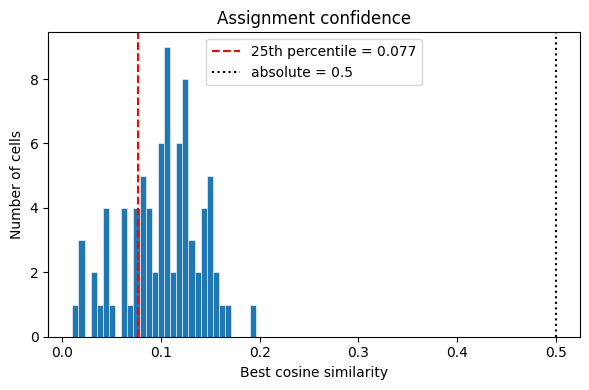

Saved → ../outputs/figures/margin_histogram.png


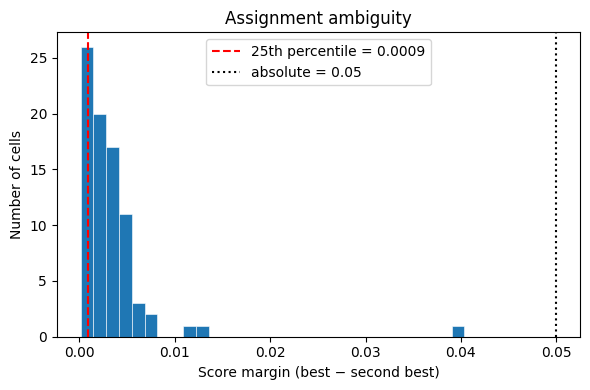

In [9]:
# =========================
# 4b. Confidence and margin histograms (calibrated)
# =========================

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(predictions["confidence"], bins=30, edgecolor="white", linewidth=0.4)

# Data-driven threshold (USED)
ax.axvline(
    similarity_threshold,
    color="red",
    linestyle="--",
    label=f"25th percentile = {similarity_threshold:.3f}"
)

# Absolute baseline (for comparison only)
ax.axvline(
    DEFAULT_CONFIDENCE_THRESHOLD,
    color="black",
    linestyle=":",
    label=f"absolute = {DEFAULT_CONFIDENCE_THRESHOLD}"
)

ax.set_xlabel("Best cosine similarity")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment confidence")
ax.legend()
plt.tight_layout()
savefig("confidence_histogram.png")
plt.show()


fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(predictions["margin"], bins=30, edgecolor="white", linewidth=0.4)

# Data-driven margin threshold (USED)
ax.axvline(
    margin_threshold,
    color="red",
    linestyle="--",
    label=f"25th percentile = {margin_threshold:.4f}"
)

# Absolute baseline (for comparison only)
ax.axvline(
    DEFAULT_MARGIN_THRESHOLD,
    color="black",
    linestyle=":",
    label=f"absolute = {DEFAULT_MARGIN_THRESHOLD}"
)

ax.set_xlabel("Score margin (best − second best)")
ax.set_ylabel("Number of cells")
ax.set_title("Assignment ambiguity")
ax.legend()
plt.tight_layout()
savefig("margin_histogram.png")
plt.show()

## 5 · Biological correction function

In [10]:
def _rejection_row(config, cell_id_str, before_score, before_type, decision, extra=None):
    row = {
        "experiment": config.name,
        "cell_id": cell_id_str,
        "before_score": before_score,
        "candidate_after_score": before_score,
        "after_score": before_score,
        "before_type": before_type,
        "candidate_after_type": before_type,
        "after_type": before_type,
        "accepted": False,
        "decision": decision,
        "improvement": 0.0,
        "raw_candidate_improvement": 0.0,
        "patch_size": config.patch_size,
        "retry_diameter": config.retry_diameter,
    }
    if extra:
        row.update(extra)
    return row


def run_biological_correction_experiment(config, predictions_input, sim_matrix, masks, img_crop, assigned_tx, prototypes):
    """
    Re-run Cellpose locally around selected low-confidence cells and accept a candidate
    correction only if cosine similarity improves by at least config.accept_tolerance.
    """
    predictions_flagged = add_confidence_flags(
        pred_df=predictions_input,
        sim_matrix=sim_matrix,
        confidence_threshold=config.confidence_threshold,
        margin_threshold=config.margin_threshold,
    )

    if config.worst_quantile is not None:
        cutoff = predictions_flagged["best_similarity"].quantile(config.worst_quantile)
        selected = predictions_flagged[predictions_flagged["best_similarity"] <= cutoff].copy()
    else:
        selected = predictions_flagged[predictions_flagged["low_confidence"]].copy()

    print(f"\nRunning experiment: {config.name}")
    print(f"Selected cells: {len(selected)} / {len(predictions_flagged)}")
    print(f"Patch size: {config.patch_size}")
    print(f"Retry diameter: {config.retry_diameter}")
    print(f"Accept tolerance: {config.accept_tolerance}")

    refined_predictions = predictions_flagged.copy()
    ablation_rows = []
    proto_values = prototypes.values
    shared_genes = list(prototypes.columns)

    if not config.run_resegmentation or not CELLPOSE_AVAILABLE:
        print("Re-segmentation unavailable/skipped. Creating no-correction table.")
        for cell_id_str, row in selected.iterrows():
            ablation_rows.append(_rejection_row(config, cell_id_str, row["best_similarity"], row["predicted_cell_type"], "not_run"))
        return refined_predictions, pd.DataFrame(ablation_rows)

    model = models.CellposeModel(gpu=True)

    for cell_id_str, row in selected.iterrows():
        cell_id = parse_cell_id(cell_id_str)
        if cell_id is None:
            continue

        before_score = row["best_similarity"]
        before_type = row["predicted_cell_type"]
        ys, xs = np.where(masks == cell_id)

        if len(ys) == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_no_mask_pixels"))
            continue

        cy, cx = int(ys.mean()), int(xs.mean())
        y0 = max(0, cy - config.patch_size // 2)
        y1 = min(CROP_SIZE, cy + config.patch_size // 2)
        x0 = max(0, cx - config.patch_size // 2)
        x1 = min(CROP_SIZE, cx + config.patch_size // 2)
        patch = img_crop[y0:y1, x0:x1]

        if patch.size == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_empty_patch"))
            continue

        patch_masks, _, _ = model.eval(patch, diameter=config.retry_diameter, batch_size=1)
        patch_cy = (y1 - y0) // 2
        patch_cx = (x1 - x0) // 2
        new_cell_id = patch_masks[patch_cy, patch_cx]

        if new_cell_id == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_no_center_cell", {"x0":x0,"x1":x1,"y0":y0,"y1":y1}))
            continue

        patch_tx = assigned_tx[
            (assigned_tx["x_local"] >= x0) & (assigned_tx["x_local"] < x1) &
            (assigned_tx["y_local"] >= y0) & (assigned_tx["y_local"] < y1)
        ].copy()

        if len(patch_tx) == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_no_transcripts", {"x0":x0,"x1":x1,"y0":y0,"y1":y1}))
            continue

        patch_tx["patch_cell"] = patch_masks[
            (patch_tx["y_local"] - y0).astype(int).clip(0, patch_masks.shape[0] - 1),
            (patch_tx["x_local"] - x0).astype(int).clip(0, patch_masks.shape[1] - 1),
        ]
        new_cell_tx = patch_tx[patch_tx["patch_cell"] == new_cell_id]

        if len(new_cell_tx) == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_no_transcripts_in_new_cell", {"x0":x0,"x1":x1,"y0":y0,"y1":y1}))
            continue

        new_expr = new_cell_tx["feature_name"].value_counts().reindex(shared_genes, fill_value=0).values.reshape(1, -1)
        if new_expr.sum() == 0:
            ablation_rows.append(_rejection_row(config, cell_id_str, before_score, before_type, "rejected_zero_expression", {"x0":x0,"x1":x1,"y0":y0,"y1":y1}))
            continue

        new_expr_norm = normalize(new_expr, norm="l2")
        scores = cos_sim(new_expr_norm, proto_values)[0]
        candidate_after_score = float(scores.max())
        candidate_after_type = prototypes.index[scores.argmax()]
        candidate_margin = float(np.sort(scores)[-1] - np.sort(scores)[-2])
        raw_improvement = candidate_after_score - before_score
        accepted = candidate_after_score >= before_score + config.accept_tolerance

        if accepted:
            refined_predictions.loc[cell_id_str, "predicted_cell_type"] = candidate_after_type
            refined_predictions.loc[cell_id_str, "best_similarity"] = candidate_after_score
            refined_predictions.loc[cell_id_str, "confidence"] = candidate_after_score
            refined_predictions.loc[cell_id_str, "margin"] = candidate_margin
            refined_predictions.loc[cell_id_str, "low_similarity"] = candidate_after_score < config.confidence_threshold
            refined_predictions.loc[cell_id_str, "low_margin"] = candidate_margin < config.margin_threshold
            refined_predictions.loc[cell_id_str, "low_confidence"] = (
                refined_predictions.loc[cell_id_str, "low_similarity"] or
                refined_predictions.loc[cell_id_str, "low_margin"]
            )

        ablation_rows.append({
            "experiment": config.name,
            "cell_id": cell_id_str,
            "before_score": before_score,
            "candidate_after_score": candidate_after_score,
            "after_score": candidate_after_score if accepted else before_score,
            "before_type": before_type,
            "candidate_after_type": candidate_after_type,
            "after_type": candidate_after_type if accepted else before_type,
            "accepted": accepted,
            "decision": "accepted_improved" if accepted else "rejected_no_improvement",
            "improvement": raw_improvement if accepted else 0.0,
            "raw_candidate_improvement": raw_improvement,
            "patch_size": config.patch_size,
            "retry_diameter": config.retry_diameter,
            "x0": x0,
            "x1": x1,
            "y0": y0,
            "y1": y1,
        })

    return refined_predictions, pd.DataFrame(ablation_rows)


## 6 · Define ablation experiments

In [11]:
# =========================
# 6. Define ablation experiments
# =========================

experiment_configs = [
    AblationConfig(
        "baseline_no_correction",
        similarity_threshold,
        margin_threshold,
        80,
        20,
        0.0,
        run_resegmentation=False,
    ),
    AblationConfig(
        "strict_patch80_diam20",
        similarity_threshold,
        margin_threshold,
        80,
        20,
        1e-4,
    ),
    AblationConfig(
        "relaxed_patch80_diam20",
        similarity_threshold,
        margin_threshold,
        80,
        20,
        0.0,
    ),
    AblationConfig(
        "larger_patch150_diam20",
        similarity_threshold,
        margin_threshold,
        150,
        20,
        0.0,
    ),
    AblationConfig(
        "worst25_patch150_diam20",
        similarity_threshold,
        margin_threshold,
        150,
        20,
        0.0,
        worst_quantile=0.25,
    ),
]

experiment_config_df = pd.DataFrame([cfg.__dict__ for cfg in experiment_configs])
display(experiment_config_df)

,name,confidence_threshold,margin_threshold,patch_size,retry_diameter,accept_tolerance,worst_quantile,run_resegmentation
0,baseline_no_correction,0.076905,0.000931,80,20,0.0000,NaN,False
1,strict_patch80_diam20,0.076905,0.000931,80,20,0.0001,NaN,True
2,relaxed_patch80_diam20,0.076905,0.000931,80,20,0.0000,NaN,True
3,larger_patch150_diam20,0.076905,0.000931,150,20,0.0000,NaN,True
4,worst25_patch150_diam20,0.076905,0.000931,150,20,0.0000,0.25,True


## 7 · Run ablation experiments

In [12]:
all_ablation_results = []
refined_by_experiment = {}

for cfg in experiment_configs:
    refined_pred, ablation_df = run_biological_correction_experiment(
        config=cfg,
        predictions_input=predictions_raw,
        sim_matrix=sim_df,
        masks=masks,
        img_crop=img_crop,
        assigned_tx=assigned_tx,
        prototypes=prototypes,
    )

    refined_by_experiment[cfg.name] = refined_pred

    if len(ablation_df) > 0:
        all_ablation_results.append(ablation_df)

if len(all_ablation_results) == 0:
    raise ValueError("No ablation results were produced.")

all_results_df = pd.concat(all_ablation_results, ignore_index=True)
all_results_df.to_csv(ALL_RESULTS_PATH, index=False)

print(f"Saved all ablation cell-level results → {ALL_RESULTS_PATH}")

print("\nDecision counts by experiment:")
decision_counts = pd.crosstab(all_results_df["experiment"], all_results_df["decision"])
display(decision_counts)

decision_counts.to_csv(OUTPUT_DIR / "ablation_decision_counts.csv")


Running experiment: baseline_no_correction
Selected cells: 38 / 82
Patch size: 80
Retry diameter: 20
Accept tolerance: 0.0
Re-segmentation unavailable/skipped. Creating no-correction table.

Running experiment: strict_patch80_diam20
Selected cells: 38 / 82
Patch size: 80
Retry diameter: 20
Accept tolerance: 0.0001


/Users/mahsa/Projects/Computational-Genomics-Project/.venv/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Running experiment: relaxed_patch80_diam20
Selected cells: 38 / 82
Patch size: 80
Retry diameter: 20
Accept tolerance: 0.0



Running experiment: larger_patch150_diam20
Selected cells: 38 / 82
Patch size: 150
Retry diameter: 20
Accept tolerance: 0.0



Running experiment: worst25_patch150_diam20
Selected cells: 21 / 82
Patch size: 150
Retry diameter: 20
Accept tolerance: 0.0


Saved all ablation cell-level results → ../outputs/ablation_all_cell_results.csv

Decision counts by experiment:


decision,accepted_improved,not_run,rejected_no_center_cell,rejected_no_improvement
experiment,,,,
baseline_no_correction,0,38,0,0
larger_patch150_diam20,14,0,10,14
relaxed_patch80_diam20,11,0,6,21
strict_patch80_diam20,10,0,6,22
worst25_patch150_diam20,9,0,7,5


## 8 · Summarize ablation metrics

In [13]:
# =========================
# 8. Summarize ablation metrics
# =========================

def summarize_experiment(name, refined_pred, ablation_df):
    before_scores = predictions_raw["best_similarity"]
    after_scores = refined_pred["best_similarity"]

    # Use the SAME calibrated thresholds used in ablation
    before_flagged = add_confidence_flags(
        predictions_raw,
        sim_df,
        similarity_threshold,
        margin_threshold,
    )

    # Make sure refined predictions also have confidence/margin flags
    refined_scored = add_confidence_flags(
        refined_pred,
        sim_df,
        similarity_threshold,
        margin_threshold,
    )

    diff = after_scores - before_scores

    n_total = len(predictions_raw)
    n_considered = len(ablation_df)
    n_accepted = int(ablation_df["accepted"].sum()) if len(ablation_df) else 0
    n_rejected = n_considered - n_accepted

    improved_scores = (
        ablation_df.loc[ablation_df["accepted"], "improvement"]
        if len(ablation_df)
        else pd.Series(dtype=float)
    )

    return {
        "experiment": name,
        "total_segmented_cells": n_total,

        "mean_cosine_before": before_scores.mean(),
        "mean_cosine_after": after_scores.mean(),
        "median_cosine_before": before_scores.median(),
        "median_cosine_after": after_scores.median(),
        "std_cosine_before": before_scores.std(),
        "std_cosine_after": after_scores.std(),

        "low_confidence_before": int(before_flagged["low_confidence"].sum()),
        "low_confidence_after": int(refined_scored["low_confidence"].sum()),
        "percent_low_confidence_before": 100 * before_flagged["low_confidence"].sum() / n_total,
        "percent_low_confidence_after": 100 * refined_scored["low_confidence"].sum() / n_total,

        "cells_considered_for_correction": n_considered,
        "cells_improved": n_accepted,
        "percent_improved_of_considered": 100 * n_accepted / max(n_considered, 1),
        "cells_rejected_or_unchanged": n_rejected,

        "average_cosine_improvement_among_improved": improved_scores.mean() if len(improved_scores) else 0,
        "max_cosine_improvement": improved_scores.max() if len(improved_scores) else 0,

        "overall_mean_delta": diff.mean(),
        "overall_max_delta": diff.max(),
        "cells_with_any_score_change": int((diff != 0).sum()),
    }


metrics_rows = []

for cfg in experiment_configs:
    refined_pred = refined_by_experiment[cfg.name]
    ablation_df = all_results_df[all_results_df["experiment"] == cfg.name].copy()
    metrics_rows.append(summarize_experiment(cfg.name, refined_pred, ablation_df))

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(EXPERIMENT_METRICS_PATH, index=False)

print(f"Saved experiment metrics → {EXPERIMENT_METRICS_PATH}")
display(metrics_df)

Saved experiment metrics → ../outputs/ablation_experiment_metrics.csv


,experiment,total_segmented_cells,mean_cosine_before,mean_cosine_after,median_cosine_before,median_cosine_after,std_cosine_before,std_cosine_after,low_confidence_before,low_confidence_after,...,percent_low_confidence_after,cells_considered_for_correction,cells_improved,percent_improved_of_considered,cells_rejected_or_unchanged,average_cosine_improvement_among_improved,max_cosine_improvement,overall_mean_delta,overall_max_delta,cells_with_any_score_change
0,baseline_no_correction,82,0.100875,0.100875,0.103892,0.103892,0.039028,0.039028,38,38,...,46.341463,38,0,0.000000,38,0.000000,0.000000,0.000000,0.000000,0
1,strict_patch80_diam20,82,0.100875,0.101201,0.103892,0.103892,0.039028,0.038740,38,38,...,46.341463,38,10,26.315789,28,0.002677,0.009165,0.000326,0.009165,10
2,relaxed_patch80_diam20,82,0.100875,0.101201,0.103892,0.103892,0.039028,0.038740,38,38,...,46.341463,38,11,28.947368,27,0.002434,0.009165,0.000326,0.009165,11
3,larger_patch150_diam20,82,0.100875,0.101016,0.103892,0.103892,0.039028,0.039070,38,38,...,46.341463,38,14,36.842105,24,0.000825,0.003107,0.000141,0.003107,14
4,worst25_patch150_diam20,82,0.100875,0.100922,0.103892,0.103892,0.039028,0.038973,38,38,...,46.341463,21,9,42.857143,12,0.000432,0.001133,0.000047,0.001133,9


In [14]:
# =========================
# Select best experiment (more meaningful criteria)
# =========================

best_row = metrics_df.sort_values(
    [
        "percent_improved_of_considered",
        "average_cosine_improvement_among_improved",
        "cells_improved",
    ],
    ascending=False
).iloc[0]

BEST_EXPERIMENT = best_row["experiment"]

best_refined_predictions = refined_by_experiment[BEST_EXPERIMENT].copy()
best_ablation_df = all_results_df[
    all_results_df["experiment"] == BEST_EXPERIMENT
].copy()

best_refined_predictions.to_csv(BEST_REFINED_PATH)

print("Best experiment:", BEST_EXPERIMENT)
display(best_row.to_frame(name="value"))
print(f"Saved best refined predictions → {BEST_REFINED_PATH}")

Best experiment: worst25_patch150_diam20


,value
experiment,worst25_patch150_diam20
total_segmented_cells,82
mean_cosine_before,0.100875
mean_cosine_after,0.100922
median_cosine_before,0.103892
median_cosine_after,0.103892
std_cosine_before,0.039028
std_cosine_after,0.038973
low_confidence_before,38
low_confidence_after,38


Saved best refined predictions → ../outputs/cell_type_predictions_refined_best.csv


## 9 · Visualize ablation experiment results

Saved → ../outputs/figures/ablation_experiment_summary.png


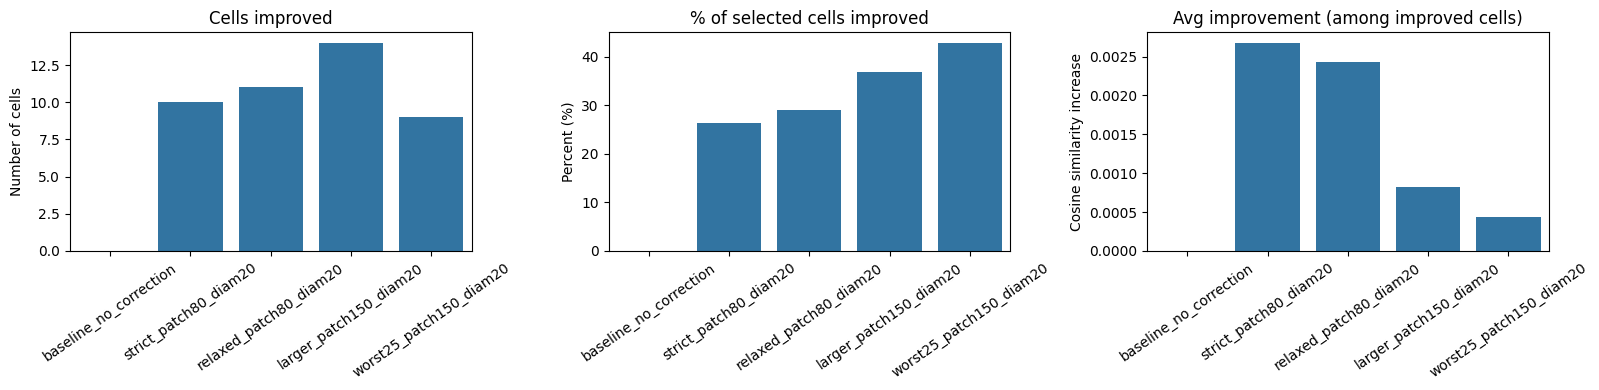

In [15]:
# =========================
# 9. Experiment summary plot
# =========================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- 1. Cells improved (absolute scale) ---
sns.barplot(data=metrics_df, x="experiment", y="cells_improved", ax=axes[0])
axes[0].set_title("Cells improved")
axes[0].set_ylabel("Number of cells")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

# --- 2. Percent improved (MOST IMPORTANT) ---
sns.barplot(data=metrics_df, x="experiment", y="percent_improved_of_considered", ax=axes[1])
axes[1].set_title("% of selected cells improved")
axes[1].set_ylabel("Percent (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

# --- 3. Average improvement (quality of correction) ---
sns.barplot(
    data=metrics_df,
    x="experiment",
    y="average_cosine_improvement_among_improved",
    ax=axes[2]
)
axes[2].set_title("Avg improvement (among improved cells)")
axes[2].set_ylabel("Cosine similarity increase")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=35)

plt.tight_layout()
savefig("ablation_experiment_summary.png")
plt.show()

## 10 · Before/after plots for best experiment

Saved → ../outputs/figures/cosine_before_after_best_histogram.png


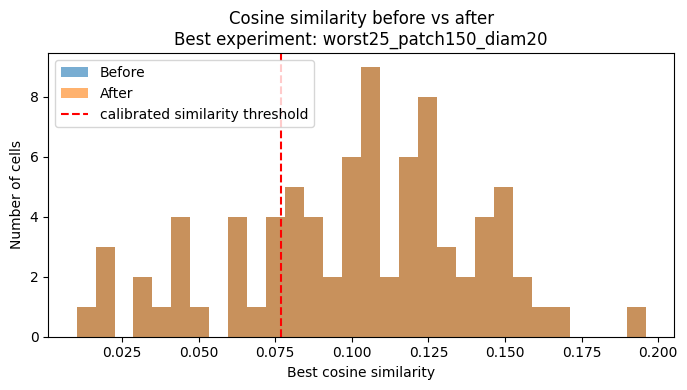

Saved → ../outputs/figures/cosine_before_after_best_boxplot.png


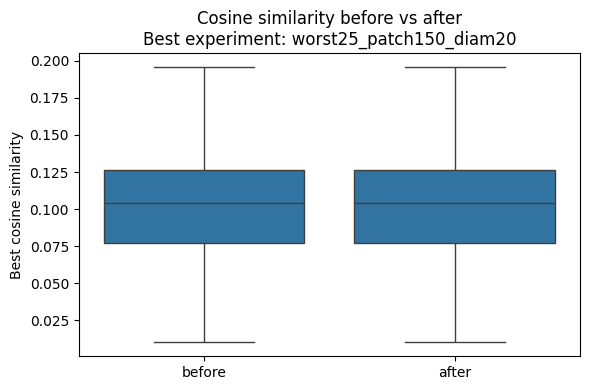

Saved → ../outputs/figures/cosine_improvement_distribution_best.png


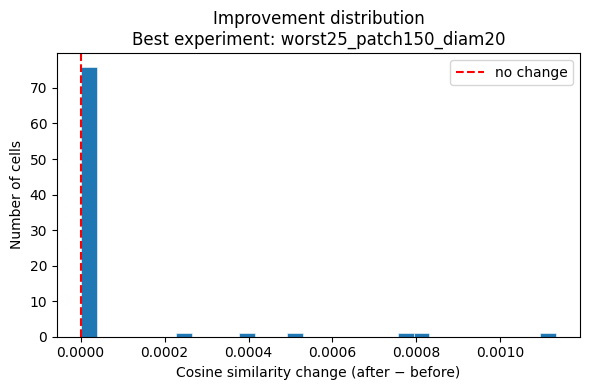

count    82.000000
mean      0.000047
std       0.000188
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.001133
Name: delta, dtype: float64
Cells improved: 9
Cells unchanged: 73
Max improvement: 0.0011334482335396828


In [16]:
# =========================
# 10. Before / after comparison for best experiment
# =========================

comparison_df = pd.DataFrame({
    "before": predictions_raw["best_similarity"],
    "after": best_refined_predictions["best_similarity"],
})

comparison_df["delta"] = comparison_df["after"] - comparison_df["before"]

comparison_long = comparison_df.reset_index().melt(
    id_vars="index",
    value_vars=["before", "after"],
    var_name="condition",
    value_name="cosine_similarity"
)

# Histogram
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(comparison_df["before"], bins=30, alpha=0.6, label="Before")
ax.hist(comparison_df["after"], bins=30, alpha=0.6, label="After")
ax.axvline(
    similarity_threshold,
    color="red",
    linestyle="--",
    label="calibrated similarity threshold"
)
ax.set_xlabel("Best cosine similarity")
ax.set_ylabel("Number of cells")
ax.set_title(f"Cosine similarity before vs after\nBest experiment: {BEST_EXPERIMENT}")
ax.legend()
plt.tight_layout()
savefig("cosine_before_after_best_histogram.png")
plt.show()

# Boxplot
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=comparison_long,
    x="condition",
    y="cosine_similarity",
    ax=ax
)
ax.set_title(f"Cosine similarity before vs after\nBest experiment: {BEST_EXPERIMENT}")
ax.set_xlabel("")
ax.set_ylabel("Best cosine similarity")
plt.tight_layout()
savefig("cosine_before_after_best_boxplot.png")
plt.show()

# Delta / improvement plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(comparison_df["delta"], bins=30, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="red", linestyle="--", label="no change")
ax.set_xlabel("Cosine similarity change (after − before)")
ax.set_ylabel("Number of cells")
ax.set_title(f"Improvement distribution\nBest experiment: {BEST_EXPERIMENT}")
ax.legend()
plt.tight_layout()
savefig("cosine_improvement_distribution_best.png")
plt.show()

print(comparison_df["delta"].describe())
print("Cells improved:", (comparison_df["delta"] > 0).sum())
print("Cells unchanged:", (comparison_df["delta"] == 0).sum())
print("Max improvement:", comparison_df["delta"].max())

count    82.000000
mean      0.000047
std       0.000188
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.001133
Name: best_similarity, dtype: float64
Cells improved: 9
Cells unchanged: 73
Mean improvement: 4.743581798167475e-05
Max improvement: 0.0011334482335396828


Saved → ../outputs/figures/cosine_improvement_distribution_best.png


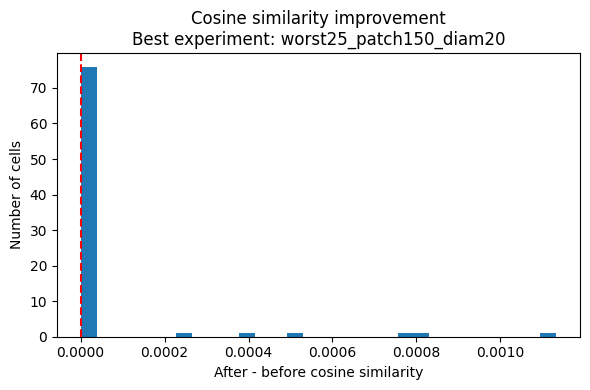

In [17]:
# =========================
# 10b. Improvement distribution
# =========================

diff = best_refined_predictions["best_similarity"] - predictions_raw["best_similarity"]
print(diff.describe())
print("Cells improved:", (diff > 0).sum())
print("Cells unchanged:", (diff == 0).sum())
print("Mean improvement:", diff.mean())
print("Max improvement:", diff.max())

plt.figure(figsize=(6, 4))
plt.hist(diff, bins=30)
plt.axvline(0, color="red", linestyle="--")
plt.title(f"Cosine similarity improvement\nBest experiment: {BEST_EXPERIMENT}")
plt.xlabel("After - before cosine similarity")
plt.ylabel("Number of cells")
plt.tight_layout()
savefig("cosine_improvement_distribution_best.png")
plt.show()


## 11 · Spatial confidence map

Saved → ../outputs/figures/confidence_map.png


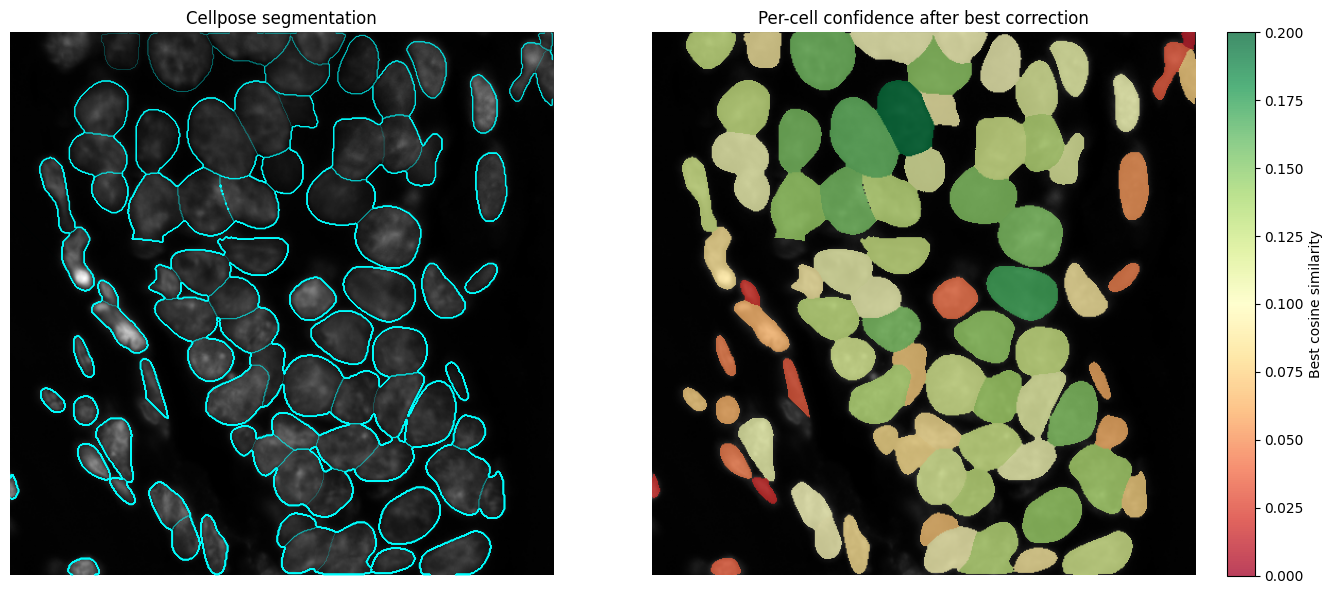

In [18]:
# =========================
# 11. Spatial confidence map
# =========================

best_predictions_with_flags = add_confidence_flags(best_refined_predictions, sim_df, DEFAULT_CONFIDENCE_THRESHOLD, DEFAULT_MARGIN_THRESHOLD)
confidence_map = np.zeros(masks.shape, dtype=float)
margin_map = np.zeros(masks.shape, dtype=float)
low_conf_map = np.zeros(masks.shape, dtype=float)

for cell_id_str, row in best_predictions_with_flags.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue
    confidence_map[masks == cell_id] = row["confidence"]
    margin_map[masks == cell_id] = row["margin"]
    low_conf_map[masks == cell_id] = 1.0 if row["low_confidence"] else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_crop, cmap="gray")
levels = np.unique(masks)
levels = levels[levels > 0]
if len(levels):
    axes[0].contour(masks, levels=levels, linewidths=0.3, colors="cyan", alpha=0.5)
axes[0].set_title("Cellpose segmentation")
axes[0].axis("off")

axes[1].imshow(img_crop, cmap="gray")
conf_masked = np.ma.masked_where(masks == 0, confidence_map)
im = axes[1].imshow(conf_masked, cmap="RdYlGn", vmin=0, vmax=max(0.2, confidence_map.max()), alpha=0.75)
plt.colorbar(im, ax=axes[1], fraction=0.046, label="Best cosine similarity")
axes[1].set_title("Per-cell confidence after best correction")
axes[1].axis("off")
plt.tight_layout()
savefig("confidence_map.png")
plt.show()


## 12 · Flagged cells overlay

Saved → ../outputs/figures/flagged_cells_overlay.png


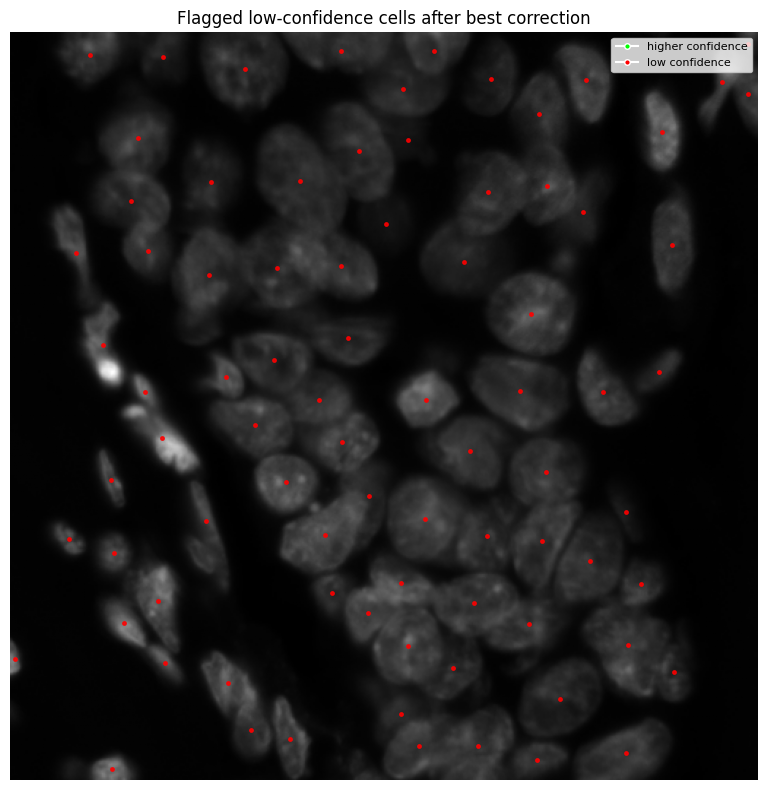

In [19]:
# =========================
# 12. Flagged cells overlay
# =========================

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_crop, cmap="gray")
for cell_id_str, row in best_predictions_with_flags.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue
    ys, xs = np.where(masks == cell_id)
    if len(ys) == 0:
        continue
    color = "red" if row["low_confidence"] else "lime"
    ax.plot(xs.mean(), ys.mean(), ".", color=color, markersize=5, alpha=0.85)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker=".", color="w", markerfacecolor="lime", markersize=8, label="higher confidence"),
    Line2D([0], [0], marker=".", color="w", markerfacecolor="red", markersize=8, label="low confidence"),
], loc="upper right", fontsize=8)
ax.set_title("Flagged low-confidence cells after best correction")
ax.axis("off")
plt.tight_layout()
savefig("flagged_cells_overlay.png")
plt.show()


## 13 · Example corrected cells

Saved → ../outputs/figures/example_corrected_cells.png


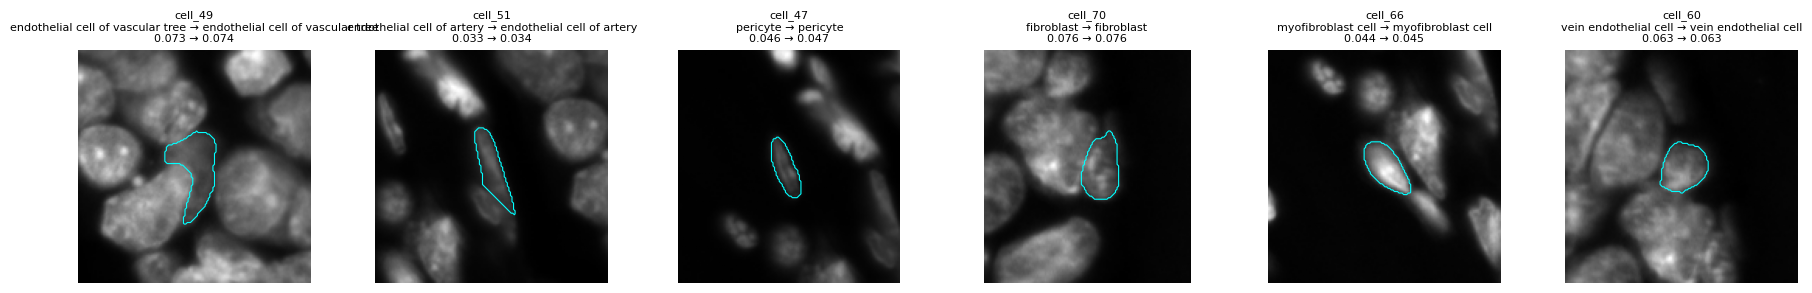

,experiment,cell_id,before_score,candidate_after_score,after_score,before_type,candidate_after_type,after_type,accepted,decision,improvement,raw_candidate_improvement,patch_size,retry_diameter,x0,x1,y0,y1
161,worst25_patch150_diam20,cell_49,0.072962,0.074096,0.074096,endothelial cell of vascular tree,endothelial cell of vascular tree,endothelial cell of vascular tree,True,accepted_improved,0.001133,0.001133,150,20,170.0,320.0,241.0,391.0
162,worst25_patch150_diam20,cell_51,0.032703,0.033529,0.033529,endothelial cell of artery,endothelial cell of artery,endothelial cell of artery,True,accepted_improved,0.000826,0.000826,150,20,59.0,209.0,258.0,408.0
160,worst25_patch150_diam20,cell_47,0.045817,0.046586,0.046586,pericyte,pericyte,pericyte,True,accepted_improved,0.000769,0.000769,150,20,0.0,143.0,230.0,380.0
168,worst25_patch150_diam20,cell_70,0.075905,0.076427,0.076427,fibroblast,fibroblast,fibroblast,True,accepted_improved,0.000522,0.000522,150,20,379.0,512.0,362.0,512.0
167,worst25_patch150_diam20,cell_66,0.044215,0.044595,0.044595,myofibroblast cell,myofibroblast cell,myofibroblast cell,True,accepted_improved,0.000380,0.000380,150,20,2.0,152.0,329.0,479.0
166,worst25_patch150_diam20,cell_60,0.062864,0.063123,0.063123,vein endothelial cell,vein endothelial cell,vein endothelial cell,True,accepted_improved,0.000259,0.000259,150,20,356.0,506.0,302.0,452.0


In [20]:
# =========================
# 13. Example corrected cells
# =========================

accepted_examples = best_ablation_df[best_ablation_df["accepted"]].copy()
accepted_examples = accepted_examples.sort_values("improvement", ascending=False).head(6)

if len(accepted_examples) == 0:
    print("No accepted examples found for the best experiment.")
else:
    saved_example_paths = []
    for idx, (_, row) in enumerate(accepted_examples.iterrows(), start=1):
        cell_id_str = row["cell_id"]
        cell_id = parse_cell_id(cell_id_str)
        ys, xs = np.where(masks == cell_id)
        if len(ys) == 0:
            print(f"Skipping {cell_id_str}: mask pixels not found.")
            continue

        cy, cx = int(ys.mean()), int(xs.mean())
        patch_size = int(row.get("patch_size", 120))
        y0 = max(0, cy - patch_size // 2)
        y1 = min(CROP_SIZE, cy + patch_size // 2)
        x0 = max(0, cx - patch_size // 2)
        x1 = min(CROP_SIZE, cx + patch_size // 2)
        patch = img_crop[y0:y1, x0:x1]
        patch_mask = masks[y0:y1, x0:x1] == cell_id

        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        ax.imshow(patch, cmap="gray")
        ax.contour(patch_mask, levels=[0.5], colors="cyan", linewidths=1.0)
        title = (
            f"{cell_id_str}\n"
            f"Before: {row['before_type']} ({row['before_score']:.3f})\n"
            f"After:  {row['after_type']} ({row['after_score']:.3f})"
        )
        ax.set_title(title, fontsize=9, pad=10)
        ax.axis("off")
        plt.tight_layout()

        output_name = f"example_corrected_cell_{idx:02d}_{cell_id_str}.png"
        savefig(output_name)
        saved_example_paths.append(FIGURES_DIR / output_name)
        plt.show()
        plt.close(fig)

    if saved_example_paths:
        print("Saved example corrected cell figures:")
        for path in saved_example_paths:
            print(f"  - {path}")

display(accepted_examples)


## 14 · Final sanity checks and report summary

In [21]:
# =========================
# 14. Final sanity checks
# =========================

print("Notebook 04 sanity check")
print("------------------------")
print(f"Cells evaluated:                  {len(cells):,}")
print(f"Genes per cell:                   {cells.shape[1]:,}")
print(f"Prototype cell types:             {prototypes.shape[0]:,}")
print(f"Prediction rows:                  {len(predictions_raw):,}")
print(f"Best experiment:                  {BEST_EXPERIMENT}")
print(f"Best refined prediction path:     {BEST_REFINED_PATH}")
print(f"All cell-level results path:      {ALL_RESULTS_PATH}")
print(f"Experiment metrics path:          {EXPERIMENT_METRICS_PATH}")
print(f"Marker heatmap path:              {FIGURES_DIR / 'marker_gene_heatmap_ordered.png'}")
print(f"Confidence map path:              {FIGURES_DIR / 'confidence_map.png'}")
print(f"Flagged overlay path:             {FIGURES_DIR / 'flagged_cells_overlay.png'}")

assert len(cells) == len(predictions_raw)
assert cells.shape[1] == prototypes.shape[1]
assert BEST_REFINED_PATH.exists()
assert ALL_RESULTS_PATH.exists()
assert EXPERIMENT_METRICS_PATH.exists()
print("\nNotebook 04 completed successfully.")


Notebook 04 sanity check
------------------------
Cells evaluated:                  82
Genes per cell:                   5,054
Prototype cell types:             8
Prediction rows:                  82
Best experiment:                  worst25_patch150_diam20
Best refined prediction path:     ../outputs/cell_type_predictions_refined_best.csv
All cell-level results path:      ../outputs/ablation_all_cell_results.csv
Experiment metrics path:          ../outputs/ablation_experiment_metrics.csv
Marker heatmap path:              ../outputs/figures/marker_gene_heatmap_ordered.png
Confidence map path:              ../outputs/figures/confidence_map.png
Flagged overlay path:             ../outputs/figures/flagged_cells_overlay.png

Notebook 04 completed successfully.


In [22]:
# =========================
# 14b. Short result summary for report draft
# =========================

best_metrics = metrics_df[metrics_df["experiment"] == BEST_EXPERIMENT].iloc[0]
print("Report-ready summary:")
print("---------------------")
print(f"We evaluated {int(best_metrics['total_segmented_cells'])} segmented cells using {cells.shape[1]} shared genes and {prototypes.shape[0]} scRNA-seq-derived cell-type prototypes.")
print(f"The best correction setting was '{BEST_EXPERIMENT}', which improved {int(best_metrics['cells_improved'])} out of {int(best_metrics['cells_considered_for_correction'])} considered low-confidence cells.")
print(f"Mean cosine similarity changed from {best_metrics['mean_cosine_before']:.4f} to {best_metrics['mean_cosine_after']:.4f}.")
print(f"The average accepted-cell improvement was {best_metrics['average_cosine_improvement_among_improved']:.4f}, with a maximum improvement of {best_metrics['max_cosine_improvement']:.4f}.")
print("This suggests that the biological correction pipeline can improve a subset of low-confidence cells, but the global shift in cosine similarity may remain modest.")


Report-ready summary:
---------------------
We evaluated 82 segmented cells using 5054 shared genes and 8 scRNA-seq-derived cell-type prototypes.
The best correction setting was 'worst25_patch150_diam20', which improved 9 out of 21 considered low-confidence cells.
Mean cosine similarity changed from 0.1009 to 0.1009.
The average accepted-cell improvement was 0.0004, with a maximum improvement of 0.0011.
This suggests that the biological correction pipeline can improve a subset of low-confidence cells, but the global shift in cosine similarity may remain modest.


In [23]:
# =========================
# Final ablation summary table
# =========================

summary_table = metrics_df[[
    "experiment",
    "cells_improved",
    "mean_cosine_before",
    "mean_cosine_after",
    "overall_mean_delta",
    "max_cosine_improvement"
]].copy()

summary_table = summary_table.sort_values("overall_mean_delta", ascending=False)

display(summary_table)

# Save
summary_table.to_csv(OUTPUT_DIR / "final_ablation_summary_table.csv", index=False)

,experiment,cells_improved,mean_cosine_before,mean_cosine_after,overall_mean_delta,max_cosine_improvement
2,relaxed_patch80_diam20,11,0.100875,0.101201,0.000326,0.009165
1,strict_patch80_diam20,10,0.100875,0.101201,0.000326,0.009165
3,larger_patch150_diam20,14,0.100875,0.101016,0.000141,0.003107
4,worst25_patch150_diam20,9,0.100875,0.100922,0.000047,0.001133
0,baseline_no_correction,0,0.100875,0.100875,0.000000,0.000000


In [24]:
# =========================
# Percent improvement table
# =========================

percent_table = metrics_df.copy()

percent_table["percent_cells_improved"] = (
    percent_table["cells_improved"] / percent_table["cells_considered_for_correction"] * 100
)

percent_table["percent_low_conf_before"] = (
    percent_table["low_confidence_before"] / percent_table["total_segmented_cells"] * 100
)

percent_table["percent_low_conf_after"] = (
    percent_table["low_confidence_after"] / percent_table["total_segmented_cells"] * 100
)

display(percent_table[[
    "experiment",
    "percent_cells_improved",
    "percent_low_conf_before",
    "percent_low_conf_after"
]])

,experiment,percent_cells_improved,percent_low_conf_before,percent_low_conf_after
0,baseline_no_correction,0.000000,46.341463,46.341463
1,strict_patch80_diam20,26.315789,46.341463,46.341463
2,relaxed_patch80_diam20,28.947368,46.341463,46.341463
3,larger_patch150_diam20,36.842105,46.341463,46.341463
4,worst25_patch150_diam20,42.857143,46.341463,46.341463


In [25]:
# =========================
# Decision breakdown per experiment
# =========================

decision_table = (
    all_results_df
    .groupby(["experiment", "decision"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(decision_table)

# Save
decision_table.to_csv(OUTPUT_DIR / "decision_breakdown_table.csv", index=False)

decision,experiment,accepted_improved,not_run,rejected_no_center_cell,rejected_no_improvement
0,baseline_no_correction,0,38,0,0
1,larger_patch150_diam20,14,0,10,14
2,relaxed_patch80_diam20,11,0,6,21
3,strict_patch80_diam20,10,0,6,22
4,worst25_patch150_diam20,9,0,7,5


In [26]:
# =========================
# Improvement statistics table
# =========================

improvement_stats = []

for exp in metrics_df["experiment"]:
    df = all_results_df[all_results_df["experiment"] == exp]
    
    stats = {
        "experiment": exp,
        "mean_improvement": df["improvement"].mean(),
        "median_improvement": df["improvement"].median(),
        "std_improvement": df["improvement"].std(),
        "max_improvement": df["improvement"].max(),
        "num_positive": (df["improvement"] > 0).sum(),
        "num_negative": (df["improvement"] < 0).sum(),
    }
    
    improvement_stats.append(stats)

improvement_stats_df = pd.DataFrame(improvement_stats)
display(improvement_stats_df)

,experiment,mean_improvement,median_improvement,std_improvement,max_improvement,num_positive,num_negative
0,baseline_no_correction,0.000000,0.0,0.000000,0.000000,0,0
1,strict_patch80_diam20,0.000705,0.0,0.001696,0.009165,10,0
2,relaxed_patch80_diam20,0.000705,0.0,0.001696,0.009165,11,0
3,larger_patch150_diam20,0.000304,0.0,0.000668,0.003107,14,0
4,worst25_patch150_diam20,0.000185,0.0,0.000341,0.001133,9,0


In [27]:
# =========================
# Best experiment summary table
# =========================

best_summary = best_row.to_frame(name="value")

display(best_summary)

best_summary.to_csv(OUTPUT_DIR / "best_experiment_summary_table.csv")

,value
experiment,worst25_patch150_diam20
total_segmented_cells,82
mean_cosine_before,0.100875
mean_cosine_after,0.100922
median_cosine_before,0.103892
median_cosine_after,0.103892
std_cosine_before,0.039028
std_cosine_after,0.038973
low_confidence_before,38
low_confidence_after,38


In [28]:
# =========================
# Export to LaTeX
# =========================

latex_table = summary_table.to_latex(index=False, float_format="%.4f")
print(latex_table)

\begin{tabular}{lrrrrr}
\toprule
experiment & cells_improved & mean_cosine_before & mean_cosine_after & overall_mean_delta & max_cosine_improvement \\
\midrule
relaxed_patch80_diam20 & 11 & 0.1009 & 0.1012 & 0.0003 & 0.0092 \\
strict_patch80_diam20 & 10 & 0.1009 & 0.1012 & 0.0003 & 0.0092 \\
larger_patch150_diam20 & 14 & 0.1009 & 0.1010 & 0.0001 & 0.0031 \\
worst25_patch150_diam20 & 9 & 0.1009 & 0.1009 & 0.0000 & 0.0011 \\
baseline_no_correction & 0 & 0.1009 & 0.1009 & 0.0000 & 0.0000 \\
\bottomrule
\end{tabular}

